In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [2]:
# read the data frame
df = pd.read_csv('king_county_house_pandas_filled.csv')

In [3]:
# Setting thresholds
lot_thre = df['sqft_lot'].quantile(0.95)

historic_thre = 70

condition_thre = np.median(df['condition'].unique())

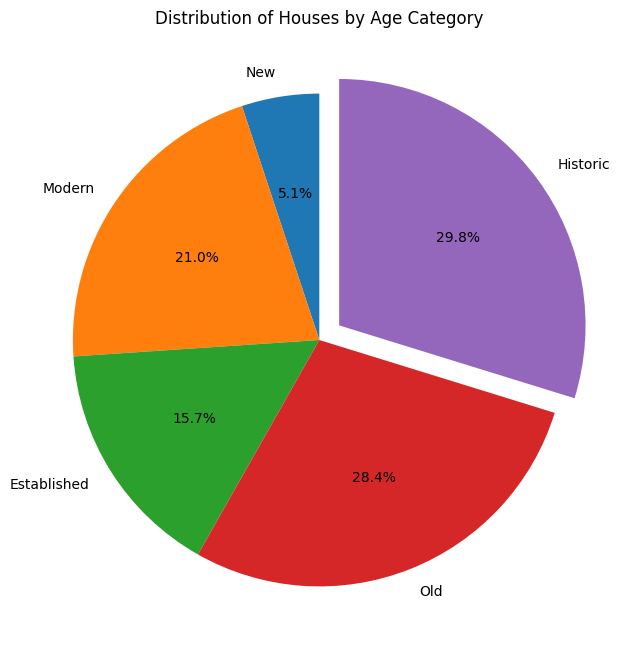

In [4]:

df['house_age_category'] = pd.cut(
    df['house_age'],
    bins=[0, 15, 30, 45, 70, df['house_age'].max()],
    labels=["New", "Modern", "Established", "Old", "Historic"]
)

house_age_counts = df['house_age_category'].value_counts().sort_index()

plt.figure(figsize=(8, 8))
explode = [0, 0, 0, 0, 0.1]  # highlight "Historic"
plt.pie(
    house_age_counts,
    labels=house_age_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    explode=explode
)

plt.title("Distribution of Houses by Age Category")
plt.show()

In [5]:
plot_data = df[df['house_age'] > historic_thre].copy()
plot_data['big_lot'] = plot_data['sqft_lot'] > lot_thre
plot_data['size_scaled'] = plot_data['sqft_lot'] / 10000

# Create map
fig = px.scatter_mapbox(
    plot_data,
    lat="lat",
    lon="long",
    size="size_scaled",
    hover_data={
        "price": True,
        "sqft_living": True,
        "sqft_lot": True,
        "bathrooms": True,
        "lat": False,
        "long": False
    },
    zoom=9,
    height=700,
    title="Geographical Distribution of Historic Houses (Size = Lot Size)"
)

# 👇 Force single color + outline
fig.update_traces(marker=dict(color="black"))

# Map style
fig.update_layout(
    mapbox_style="open-street-map"
)

fig.show()

/tmp/ipykernel_21080/808730858.py:6: DeprecationWarning: *scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = px.scatter_mapbox(


In [6]:
# Non-renovated houses meeting all conditions set by the client
filtered_orig = df[
    (df['waterfront'] == 0) &
    (df['sqft_lot'] > lot_thre) &
    (
        (df['bathrooms'] >= 4) | 
        (df['sqft_living'] > df['sqft_living15'])
    ) &
    (df['house_age'] > historic_thre) &
    (df['condition'] > condition_thre) &
    (df['if_renovated'] == 0)
].copy()


top_10_orig = filtered_orig.sort_values(
    by=['sqft_lot', 'sqft_living'],
    ascending=[False, False]
).head(10)


KeyError: 'if_renovated'

In [ ]:

top_10_orig = top_10_orig.dropna(subset=['lat', 'long']).copy()
top_10_orig['label'] = "House " + (top_10_orig.index.astype(str))
top_10_orig['size_scaled'] = top_10_orig['sqft_lot'] / 10000

fig = px.scatter_map(
    top_10_orig,
    lat="lat",
    lon="long",
    size="size_scaled",
    text="label", 
    color_discrete_sequence=["red"], 
    hover_data={
        "price": True,
        "sqft_living": True,
        "sqft_lot": True,
        "bathrooms": True,
        "yr_built": True,
        "condition": True,
        "lat": False,
        "long": False
    },
    zoom=10,
    height=700,
    title="Top 10 Client-Matching Non-Renovated Properties"
)

fig.update_traces(
    textposition="top center"
)

fig.update_layout(
    map_center={
        "lat": top_10_orig['lat'].mean(),
        "lon": top_10_orig['long'].mean()
    }
)

fig.show()

In [ ]:
filtered_reno = df[
    (df['waterfront'] == 0) &
    (df['sqft_lot'] > lot_thre) &
    (
        (df['bathrooms'] >= 4) | 
        (df['sqft_living'] > df['sqft_living15'])
    ) &
    (df['house_age'] > historic_thre) &
    (df['condition'] > condition_thre) &
    (df['if_renovated'] == 1)
].copy()


top_10_reno = filtered_reno.sort_values(
    by=['sqft_lot', 'sqft_living'],
    ascending=[False, False]
).head(10)

top_10_reno = top_10_reno.dropna(subset=['lat', 'long']).copy()
top_10_reno['label'] = "House " + (top_10_reno.index.astype(str))
top_10_reno['size_scaled'] = top_10_reno['sqft_lot'] / 10000

fig = px.scatter_map(
    top_10_reno,
    lat="lat",
    lon="long",
    size="size_scaled",
    text="label", 
    color_discrete_sequence=["red"], 
    hover_data={
        "price": True,
        "sqft_living": True,
        "sqft_lot": True,
        "bathrooms": True,
        "yr_built": True,
        "condition": True,
        "lat": False,
        "long": False
    },
    zoom=10,
    height=700,
    title="Top Client-Matching Renovated Properties"
)

fig.update_traces(
    textposition="top center"
)

fig.update_layout(
    map_center={
        "lat": top_10_reno['lat'].mean(),
        "lon": top_10_reno['long'].mean()
    }
)



In [ ]:
top_10_reno

,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,long,sqft_living15,sqft_lot15,date,price,house_age,if_renovated,house_age_category,label,size_scaled
16981,720079001,3.0,1.75,3320.0,478288.0,1.5,0,3,4,8,...,-121.953,2960.0,217800.0,2014-06-26,667000.0,93,1,Historic,House 16981,47.8288
13452,1822069052,5.0,2.50,2850.0,209523.0,1.0,0,0,4,7,...,-122.089,2220.0,209523.0,2014-07-09,450000.0,101,1,Historic,House 13452,20.9523
12146,3343903240,3.0,2.00,2270.0,148975.0,1.0,0,0,4,6,...,-122.195,2210.0,17388.0,2014-07-22,452000.0,126,1,Historic,House 12146,14.8975
11717,2303900045,4.0,2.50,4570.0,74487.0,2.0,0,4,5,12,...,-122.372,3810.0,74487.0,2014-06-23,1580000.0,78,1,Historic,House 11717,7.4487
3018,3377900195,4.0,5.50,6930.0,45100.0,1.0,0,0,4,11,...,-122.144,2560.0,37766.0,2014-09-29,2530000.0,76,1,Historic,House 3018,4.5100


In [ ]:
# Create three top recommendations both for orig and renov houses

top_3_orig = top_10_orig.head(3).copy()
top_3_reno = top_10_reno.head(3).copy()

top_3_orig['category'] = "Original"
top_3_reno['category'] = "Renovated"

# cleaner labels by dropping others
top_3_orig = top_3_orig.reset_index(drop=True)
top_3_reno = top_3_reno.reset_index(drop=True)

top_3_orig['label'] = "Orig " + (top_3_orig.index + 1).astype(str)
top_3_reno['label'] = "Reno " + (top_3_reno.index + 1).astype(str)

# combine datasets
top_3_all = pd.concat([top_3_orig, top_3_reno])

# plot the map with the combined data frame
fig = px.scatter_map(
    top_3_all,
    lat="lat",
    lon="long",
    size="size_scaled",
    text="label",
    color="category",  
    color_discrete_map={
        "Original": "#C20078",
        "Renovated": "#008080"
    },
    hover_data={
        "price": True,
        "sqft_living": True,
        "sqft_lot": True,
        "bathrooms": True,
        "yr_built": True,
        "condition": True,
        "lat": False,
        "long": False
    },
    zoom=10,
    height=700,
    title="Top 3 Original vs Renovated Properties"
)

fig.update_traces(textposition="top center")

fig.update_layout(
    map_center={
        "lat": top_3_all['lat'].mean(),
        "lon": top_3_all['long'].mean()
    }
)

fig.show()